EUROSTAT API Extraction

In [20]:
import pandas as pd
import eurostat
import warnings
warnings.filterwarnings('ignore')

print("Extracting European Macroeconomic Data via Eurostat API...")

# Upgraded Datasets: Using 'une_rt_m' (The Master Labour Force Survey Dataset)
datasets = {
    'Inflation': 'prc_hicp_manr',  
    'Unemployment': 'une_rt_m',   
    'Industrial_Prod': 'sts_inpr_m', 
    'Interest_Rates': 'irt_st_m'   
}

def filter_by_col(df, col_name, allowed_values):
    target_col = next((c for c in df.columns if c.lower() == col_name.lower()), None)
    if target_col:
        return df[df[target_col].isin(allowed_values)].copy()
    return df

macro_dataframes = []

for name, code in datasets.items():
    print(f"Downloading {name} ({code})...")
    df = eurostat.get_data_df(code)
    
    # 1. Fuzzy match for the Euro Area Geography Code
    geo_col = next((c for c in df.columns if 'geo' in c.lower()), None)
    if geo_col:
        available_geos = [str(g) for g in df[geo_col].unique()]
        target_code = None
        
        # Try strict matches first
        for pref in ['EA20', 'EA19', 'EA']:
            if pref in available_geos:
                target_code = pref
                break
                
        # If strict fails, grab ANY code starting with 'EA' (like EA18, EA21)
        if not target_code:
            ea_codes = [g for g in available_geos if g.startswith('EA')]
            if ea_codes:
                target_code = ea_codes[0]
                
        if target_code:
            print(f"  -> Locked onto Geography Code: {target_code}")
            df = df[df[geo_col] == target_code]
        else:
            print(f"  -> WARNING: No Euro Area code found for {name}. Debug info: {available_geos[:10]}")
            continue

    # 2. Explicitly filter the exact macroeconomic dimensions
    if name == 'Inflation':
        df = filter_by_col(df, 'coicop', ['CP00'])
        
    elif name == 'Unemployment':
        # Master dataset requires filtering by Age and Sex as well
        df = filter_by_col(df, 's_adj', ['SA'])
        df = filter_by_col(df, 'age', ['TOTAL'])
        df = filter_by_col(df, 'sex', ['T'])
        df = filter_by_col(df, 'unit', ['PC_ACT'])
        
    elif name == 'Industrial_Prod':
        # B-D = Total Industry
        df = filter_by_col(df, 'nace_r2', ['B-D'])
        # Allow both Seasonally & Calendar Adjusted (SCA) or just Seasonally Adjusted (SA)
        df = filter_by_col(df, 's_adj', ['SCA', 'SA'])
        # Allow the new 2021 base year (I21) or fallback to 2015 (I15)
        df = filter_by_col(df, 'unit', ['I21', 'I15'])

    elif name == 'Interest_Rates':
        intrt_col = next((c for c in df.columns if 'intrt' in c.lower()), None)
        if intrt_col:
            m3_val = [v for v in df[intrt_col].unique() if type(v) == str and ('M3' in v or 'M03' in v)]
            if m3_val:
                df = df[df[intrt_col] == m3_val[0]]

    # 3. Separate dates from metadata 
    date_cols = [c for c in df.columns if str(c)[0].isdigit()]
    meta_cols = [c for c in df.columns if c not in date_cols]
    
    # 4. Melt and Clean Dates
    df_melted = df.melt(id_vars=meta_cols, value_vars=date_cols, var_name='Date', value_name=name)
    df_melted['Date'] = df_melted['Date'].astype(str).str.replace('M', '-')
    df_melted['Date'] = pd.to_datetime(df_melted['Date'], errors='coerce')
    
    # Drop rows with missing values and set the index
    df_clean = df_melted.dropna(subset=['Date', name])[['Date', name]].set_index('Date')
    df_clean = df_clean[~df_clean.index.duplicated(keep='first')]
    
    macro_dataframes.append(df_clean)

# Merge all indicators into one master dataframe
df_macro_master = pd.concat(macro_dataframes, axis=1).sort_index()
df_macro_master = df_macro_master[df_macro_master.index >= '2005-01-01']

print("\nEurostat Extraction Complete. Shape:", df_macro_master.shape)
print(df_macro_master.head())

Extracting European Macroeconomic Data via Eurostat API...
  -> Locked onto Geography Code: EA20
  -> Locked onto Geography Code: EA21
  -> Locked onto Geography Code: EA20
  -> Locked onto Geography Code: EA

Eurostat Extraction Complete. Shape: (257, 4)
            Inflation  Unemployment  Industrial_Prod  Interest_Rates
Date                                                                
2005-01-01        1.9           9.3             98.3          2.0771
2005-02-01        2.1           9.3             98.1          2.0585
2005-03-01        2.2           9.3             98.0          2.0567
2005-04-01        2.1           9.4             99.5          2.0757
2005-05-01        2.0           9.3             98.2          2.0700


Macroeconomic Indicator Plot

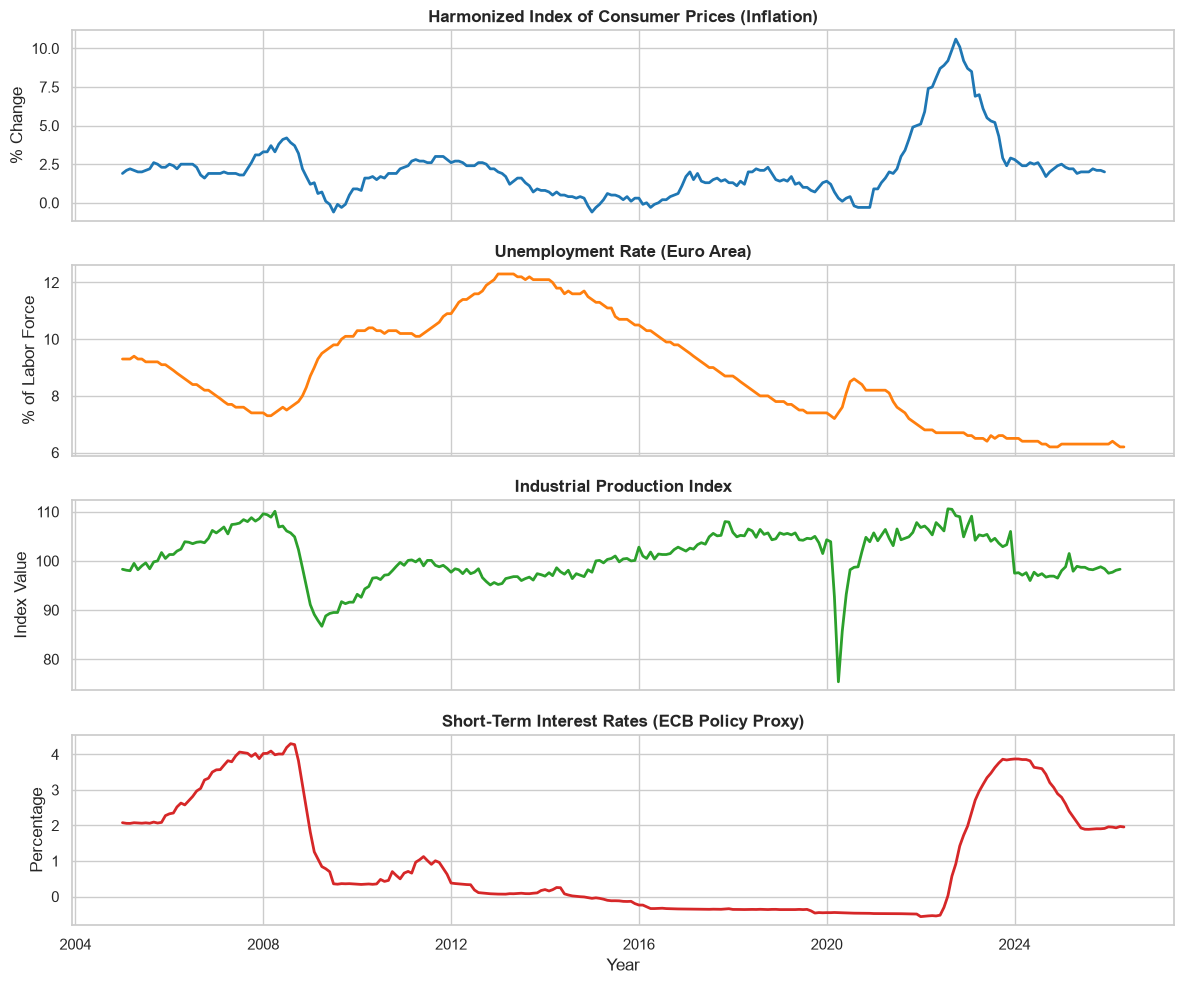

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set clean styling for the plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 10), sharex=True)

# 1. Inflation Rate Trend
axes[0].plot(df_macro_master.index, df_macro_master['Inflation'], color='#1f77b4', linewidth=2)
axes[0].set_title('Harmonized Index of Consumer Prices (Inflation)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% Change')

# 2. Unemployment Rate Trend
axes[1].plot(df_macro_master.index, df_macro_master['Unemployment'], color='#ff7f0e', linewidth=2)
axes[1].set_title('Unemployment Rate (Euro Area)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% of Labor Force')

# 3. Industrial Production Trend
axes[2].plot(df_macro_master.index, df_macro_master['Industrial_Prod'], color='#2ca02c', linewidth=2)
axes[2].set_title('Industrial Production Index', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Index Value')

# 4. Interest Rates Trend
axes[3].plot(df_macro_master.index, df_macro_master['Interest_Rates'], color='#d62728', linewidth=2)
axes[3].set_title('Short-Term Interest Rates (ECB Policy Proxy)', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Percentage')

# Formatting the overall timeline
plt.xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

FinBERT and Semantic Index

In [ ]:
# TODO